# NLP 2026
# Lab 1: From Tokens to Language Models

As discussed in the first lectures, tokenization is a fundamental step in **Natural Language Processing (NLP)** 🧠💬 that transforms raw text into structured data for computational models. In this lab, you will explore different **tokenization techniques** 📝, preprocess text data 🔍, and implement **tokenization pipelines** using popular NLP libraries 🏗️. Next, we explore N-gram language models 📊 as a foundational approach 🧱 to modeling natural language statistically 📈. These models form the conceptual foundation 🧠 of the neural language models 🤖🧠 that we will explore later in the course 🚀📚.

You will also gain **hands-on experience** with **Hugging Face Datasets 🤗📚**, while assessing the impact of tokenization choices on downstream NLP tasks. 

By the end of this lab, you will have a **strong foundation** in tokenization techniques and be able to apply them effectively in **real-world NLP applications**, including implementing a N-gram language modeling pipeline🌍.  

---

### 🎯 **Learning Goals**  

By the end of this lab, you should be able to:  

✅ **Understand the role of tokenization in NLP** 🧠💡  
✅ **Explain why tokenization is important** and how it affects text processing 📖🔍  
✅ **Implement different tokenization techniques** – Apply **word** 📝, **subword** 🔢, and **character-level** 🔠 tokenization using built-in libraries.  
✅ **Use Hugging Face Datasets** 🤗📊 – Load and preprocess text datasets efficiently.  
✅ **Evaluate tokenization impact** 📉🔎 – Analyze how different tokenization methods influence model performance. 
✅ **Identify challenges in tokenization** ❗🔍 – Recognize issues like **out-of-vocabulary (OOV) words**, **ambiguity**, and **multilingual tokenization** 🌍.  
✅ **Identify challenges in tokenization** ❗🔍 – Recognize issues like **out-of-vocabulary (OOV) words**, **ambiguity** and **multilingual tokenization** 🌍.  
✅ **Build and use N-gram language models** 🧠📊 - Understand how unigrams, bigrams and higher-order n-grams capture context in text, implement efficient N-gram counting with Python and design an object-oriented N-gram Language Model that supports probability lookup and text generation.  
✅ **Generate, smooth and evaluate language models** 🚀📉 - Apply different techniques for text generation and compare models with different values of $N$ and advanced techniques such as interpolation or backoff.

### Score breakdown

| Exercise            | Points |
|---------------------|--------|
| [Exercise 1](#e1)   | 3      |
| [Exercise 2](#e2)   | 6      |
| [Exercise 3](#e3)   | 4      |
| [Exercise 4](#e4)   | 6      |
| [Exercise 5](#e5)   | 4      |
| [Exercise 6](#e6)   | 7      |
| [Exercise 7](#e7)   | 4      |
| [Exercise 8](#e8)   | 4      |
| [Exercise 9](#e9)   | 4      |
| [Exercise 10](#e10) | 6      |
| [Exercise 11](#e11) | 4      |
| [Exercise 12](#e12) | 4      |
| [Exercise 13](#e13) | 4      |
| [Exercise 14](#e14) | 4      |
| [Exercise 15](#e15) | 4      |
| [Exercise 16](#e16) | 4      |
| [Exercise 17](#e17) | 4      |
| [Exercise 18](#e18) | 4      |
| [Exercise 19](#e19) | 20     |
| Total               | 100    |

This score will be scaled down to X.X and that will be your final lab score.

### 📌 **Instructions for Delivery** (📅 **Deadline: X/Feb 18:00**, 🎭 *wildcards possible*)  

✅ **Submission Requirements**  
+ 📄 You need to submit a **notebook** 📓 with the code, appropriate comments and figures in all questions. Make sure to have a mix of code (some explanations needed if not clear what you implement), figures to support the answers or your claims and proper amount of text to explain your reasoning, answer etc.  
+ ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the report are also visible in your **executed notebook**.
+ You can work on Google Collab (or other environments), but you need to make sure that your delivered notebook is executed properly.

✅ **Collaboration & Integrity**  
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** below.  
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.  
+ 📢 **Mandatory Disclosure**:  
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.  
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.  
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.   

**A note from Jerry on using Language Models (LMs)**

If you try hard enough, you will likely get away with cheating (that does not only apply to LMs). Fortunately, our job is not to police, but rather to educate you. So, please consider the following:

- We assume that you are taking this course to learn something! LMs are not always right (they often fail in silly ways). This course should prepare you to detect when they are wrong!
- We don't restrict the use of LMs because we see the value of being helped when coding (esp. in the context of a course like NLP). Based on what we saw last year in your deliverables, it's pretty clear when you "copy" some code and then you struggle to interpret the results. This is the essence of this course and of the skills you should try build for yourself: Many people can run fancy models these days but not many people can interpret the results correctly. Try to be the latter ones.

## 0. Preparation

In this section we will import the necessary libraries. But first we will explain how to install a python environment using conda. You don't have to do it this way, and maybe you already have one prepared.

First, you can install Miniconda environment manager. Here are the instructions https://www.anaconda.com/docs/getting-started/miniconda/install.
It can create virtual environments with different python versions and separately installed libraries (useful if  you work on several projects). You can read more about managing environments here: https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html
You might need a restart of your system to complete the installation.

The commands below are commented out so that you don't run them by mistake. You will have to copy them to the terminal of your operating system.

This command creates a new environment called `nlplab2026` (you can change the name if you'd like) and python version `3.12`.

In [1]:
# conda create -n nlplab2026 python=3.12

The environment should be installed, but it is not activated yet. To do it you can use the following command:

In [2]:
# conda activate nlplab2026

The activation of the environment is indicated by the prompt (the name of the environment should be in parentheses), for example: `(nlplab2026) pawelmaka@MacBook ~ % `

Now, we are ready to install the required packages using `pip`:

In [3]:
# pip install --user --upgrade jupyter
# pip install tqdm
# pip install datasets
# pip install matplotlib
# pip install numpy
# pip install pandas

OK


Sometimes, the libraries don't work together well on some systems. This situation could necessitate the installation of a library's particular version. To do so you can use the following command (putting the library and version you need)

In [4]:
# pip install matplotlib==3.10.8 --force-reinstall -v

When you are starting jupyter notebook make sure to first activate the environment `nlplab2026`.

### Imports

In [1]:
import re
from collections import Counter

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm

/Users/prikolchik/Documents/labs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Intro to regular expressions

In this introduction section, you can practice the use of regular expressions in python. You can find the documentation here: [https://docs.python.org/3/library/re.html](https://docs.python.org/3/library/re.html). The main functions of the re module are:
- `re.search()` - searches for a pattern in a string, returns the first match,
- `re.findall()` - similar to `search()`, but returns a list of all matches,
- `re.sub()` - replaces the matches with a string.

All above functions accept the regular expression pattern as their argument. The patterns are strings that represent the rules for matching the text. In python they start with `r` character, e.g. `r'\d'` is a pattern that matches a digit.

Let us start with a simple example. We will search for the word "world" in the string "Hello, world!".

In [2]:
text = "Hello, world!"
pattern = r'world'
match = re.search(pattern, text)
print(match)

<re.Match object; span=(7, 12), match='world'>


The `search()` function returns a match object that tells us where the match was found (`span` argument) and the exact part of the string that matched the pattern (`group` argument).

Below you can find the examples from the lecture.

In [3]:
# Disjunctions
pattern = r'[wW]oodchuck'  # matches both "woodchuck" and "Woodchuck"
pattern = r'[1234567890]'  # matches any digit, you can also use r'\d' or r'[0-9]'
pattern = r'[0-9]'  # matches any digit
pattern = r'[A-Z]'  # matches any uppercase letter
pattern = r'[a-z]'  # matches any lowercase letter
pattern = r'[A-Za-z]'  # matches any letter

# Disjunctions with pipe |
pattern = r'groundhog|Woodchuck'  # matches both "groundhog" and "Woodchuck"

# Negation (only when in [])
pattern = r'[^0-9]'  # matches any character that is not a digit
pattern = r'[^Ss]'  # matches any character that is not 'S' or 's'
pattern = r'a\^b'  # matches the string "a^b"

# Quantifiers (+, *, ?, .)
pattern = r'baa+'  # matches "ba" followed by one or more "a" (e.g. "baa", "baaa", "baaaa", ...)
pattern = r'oo*h'  # matches "o" followed by zero or more "o" and then "h" (e.g. "oh", "ooh", "oooh", ...)
pattern = r'colou?r'  # matches "color" and "colour"
pattern = r'beg.n'  # matches "begun", "begin", "begnn", ...

# Anchors (^, $)
pattern = r'^Hello'  # matches "Hello" at the beginning of the string
pattern = r'world!$'  # matches "world!" at the end of the string

## 1. Hugging Face Datasets

We will be using Hugging Face Datasets library ([https://huggingface.co/datasets](https://huggingface.co/datasets)). You can find the detailed documentation and tutorials here: [https://huggingface.co/docs/datasets/en/index](https://huggingface.co/docs/datasets/en/index)

In this lab, we will load “tweet_eval” dataset and specifically the __emoji__ subset. For tokenization, we will only consider the text (contents of the tweet) but in this section we will also look at the labels. The description of the dataset is available in the dataset's card at [https://huggingface.co/datasets/cardiffnlp/tweet_eval](https://huggingface.co/datasets/cardiffnlp/tweet_eval)

In order to load a dataset simply call load_dataset function specifying the dataset name. You can find many more datasets at the huggingface website.

In [4]:
dataset = datasets.load_dataset('tweet_eval', 'emoji')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
})


The loaded dataset contains three subsets (“train”, “validation”, and “test”). Each consists of two columns: “text” and “label”. Label is an integer from 0 to 19 representing an emoji. See the dataset's card for more information. We can access the elements of the dataset like so:

In [5]:
for i in range(10):
    print(dataset['train'][i])

{'text': 'Sunday afternoon walking through Venice in the sun with @user ️ ️ ️ @ Abbot Kinney, Venice', 'label': 12}
{'text': "Time for some BBQ and whiskey libations. Chomp, belch, chomp! (@ Lucille's Smokehouse Bar-B-Que)", 'label': 19}
{'text': 'Love love love all these people ️ ️ ️ #friends #bff #celebrate #blessed #sundayfunday @ San…', 'label': 0}
{'text': '️ ️ ️ ️ @ Toys"R"Us', 'label': 0}
{'text': 'Man these are the funniest kids ever!! That face! #HappyBirthdayBubb @ FLIPnOUT Xtreme', 'label': 2}
{'text': '#sandiego @ San Diego, California', 'label': 11}
{'text': 'My little ️ ️ ️ ️ ️ #ObsessedWithMyDog @ Cafe Solstice Capitol Hill', 'label': 0}
{'text': 'More #tinyepic things #tinyepicwestern, this one is crazy @user I may be one of your…', 'label': 19}
{'text': 'Last night ️ @ Omnia Night Club At Caesars Palace', 'label': 0}
{'text': 'friendship at its finest. ....#pixar #toystory #buzz #woody #friends #friendship #bff…', 'label': 7}


You can easily cast the dataset to the pandas DataFrame.

In [6]:
tweet_train_df = pd.DataFrame(dataset['train'])
print(tweet_train_df)

                                                    text  label
0      Sunday afternoon walking through Venice in the...     12
1      Time for some BBQ and whiskey libations. Chomp...     19
2      Love love love all these people ️ ️ ️ #friends...      0
3                                    ️ ️ ️ ️ @ Toys"R"Us      0
4      Man these are the funniest kids ever!! That fa...      2
...                                                  ...    ...
44995  Here to celebrate the Nunez wedding! Love my b...      0
44996  1 night in Paris.... Wait... @ Paris Las Vegas...      1
44997  Be safe this weekend everyone. #happylaborday ...     11
44998          Pizza (@ Five50 - @user in Las Vegas, NV)      1
44999  my mini is perfect, no one deserves her @ Las ...     13

[45000 rows x 2 columns]


Even though we will not use the labels in this lab, we can plot their distribution in the training subset.

### Dataset's filter function
We can filter the examples using ```filter()``` method. See this link for more details https://huggingface.co/docs/datasets/en/use_dataset. Here is an example of filtering the short tweets (less than 20 characters) from the ```train``` subset.

In [7]:
short_tweets = dataset['train'].filter(lambda example: len(example['text']) < 20)
print(short_tweets)

Dataset({
    features: ['text', 'label'],
    num_rows: 506
})


In [8]:
for i in range(10):
    print(short_tweets[i])

{'text': '️ ️ ️ ️ @ Toys"R"Us', 'label': 0}
{'text': '️ @ Columbia River', 'label': 12}
{'text': 'My weekend: @user 3', 'label': 6}
{'text': 'good day today', 'label': 3}
{'text': 'My last RT...', 'label': 2}
{'text': '@ On Lake Cowichan', 'label': 13}
{'text': '@ Macroplaza', 'label': 4}
{'text': '@ BART Train', 'label': 6}
{'text': '️ 4 a tbh&amp; rate', 'label': 0}
{'text': '@user Oh nice!!', 'label': 14}


### Dataset's map function
Datasets library contains a very useful method map. It expects a function that will receive an example from the dataset. This function will be applied to all entries. We will calculate the length of the text (in characters) in each example.

In [9]:
def calculate_text_length(example):
    example['text_length'] = len(example['text'])
    return example

In [10]:
dataset = dataset.map(calculate_text_length, desc="Calculating text length")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 45000
    })
    test: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 5000
    })
})


We can plot the histogram of the text lengths.

<Axes: ylabel='Frequency'>

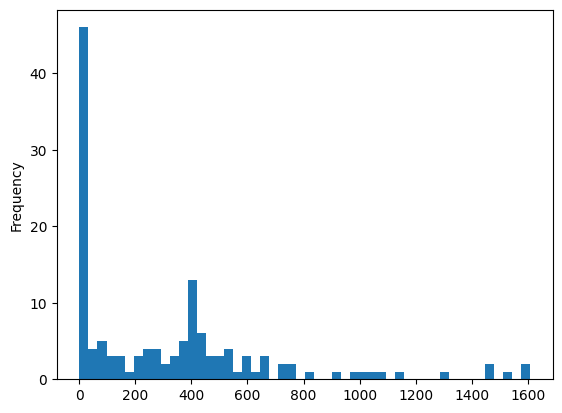

In [11]:
pd.DataFrame(dataset['train']).groupby('text_length')['text_length'].count().plot.hist(bins=50)

<a name='e1'></a>

### Exercise 1: Questions about the datasets
1. (1p) What is the size of the training, test and validation datasets?
2. (1p) What is the average length (in characters) of the tweets in the training dataset?
3. (1p) Compare the distributions of tweet lengths between training, validation, and test subsets.

training =  45000 ; test =  50000 ; validation =  5000
71.01691111111111


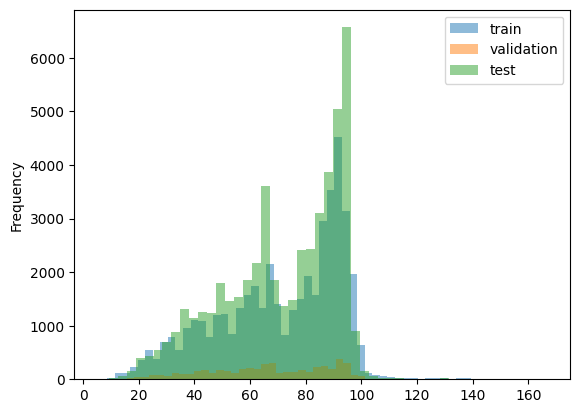

In [12]:
##### You can add code here but feel free to add/remove cells as you see fit
# 1st question
training_size = len(dataset["train"])
test_size = len(dataset["test"])
validation_size = len(dataset["validation"])
print('training = ', training_size,'; test = ', test_size,'; validation = ', validation_size)

# 2nd question
train_lengths = [len(x["text"]) for x in dataset["train"]]
print(np.mean(train_lengths))

# 3rd question
pd.DataFrame(dataset["train"])["text_length"].plot.hist(bins=50, alpha=0.5, label="train")
pd.DataFrame(dataset["validation"])["text_length"].plot.hist(bins=50, alpha=0.5, label="validation")
pd.DataFrame(dataset["test"])["text_length"].plot.hist(bins=50, alpha=0.5, label="test")
plt.legend()
plt.show()




#### Answers
1. training = 45000; test = 50000; validation = 5000
2. avg length ~ 71
3. they are all right skewed distributions

## 2. Tokenization

In this section we will preprocess the dataset by cleaning and tokenizing the entries.
Datasets library contains a very useful method map. It expects a function that will receive an example from the dataset. This function will be applied to all entries.

### 2.1 Cleaning the text

<a name='e2'></a>

### Exercise 2: Write the text cleaning function

(6p) Include at least the following steps:
1. remove comma between numbers, i.e. 15,000 -> 15000,
2. remove multiple spaces,
3. space out the punctuation (i.e. "hello, world." -> "hello , world ."),
4. three more cleaning steps of your choice.

In [13]:
def clean(text):
    """
    Cleans the text
    Args:
        text: a string that will be cleaned

    Returns: the cleaned text

    """

    # Empty text
    if text == '':
        return text

    ### YOUR CODE HERE
    # 1) remove comma between numbers
    text = re.sub(r'(?<=\d),(?=\d)', '', text)
    # 4) lowercase
    text = text.lower()
    # 5) remove repeated punctuation
    text = re.sub(r'([!?]){2,}', r'\1', text)
    # 3) space out punctuation
    text = re.sub(r'([.,!?;:()"\'])', r' \1 ', text)
    # 6) remove # symbol
    text = re.sub(r'#(\w+)', r'\1', text)
    # 2) remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    ### YOUR CODE ENDS HERE

    return text

Let's test your cleaning function

In [14]:
for i in range(5):
    original = dataset['train'][i]['text']
    cleaned = clean(original)
    print('original:', original)
    print('cleaned:', cleaned)
    print()

original: Sunday afternoon walking through Venice in the sun with @user ️ ️ ️ @ Abbot Kinney, Venice
cleaned: sunday afternoon walking through venice in the sun with @user ️ ️ ️ @ abbot kinney , venice

original: Time for some BBQ and whiskey libations. Chomp, belch, chomp! (@ Lucille's Smokehouse Bar-B-Que)
cleaned: time for some bbq and whiskey libations . chomp , belch , chomp ! ( @ lucille ' s smokehouse bar-b-que )

original: Love love love all these people ️ ️ ️ #friends #bff #celebrate #blessed #sundayfunday @ San…
cleaned: love love love all these people ️ ️ ️ friends bff celebrate blessed sundayfunday @ san…

original: ️ ️ ️ ️ @ Toys"R"Us
cleaned: ️ ️ ️ ️ @ toys " r " us

original: Man these are the funniest kids ever!! That face! #HappyBirthdayBubb @ FLIPnOUT Xtreme
cleaned: man these are the funniest kids ever ! that face ! happybirthdaybubb @ flipnout xtreme



Let's finally use the ```map()``` method and apply your `clean()` function to all entries of the dataset. We are overriding the `text` field with the cleaned version.

In [15]:
def clean_example(example):
    """
    Cleans the example from the Dataset. Uses clean() function for cleaning.
    Args:
        example: an example from the Dataset

    Returns: update example containing 'clean' column

    """
    text = example['text']
    clean_text = clean(text)

    # Update the example with the cleaned text
    example['text'] = clean_text.strip()
    return example


dataset = dataset.map(clean_example, desc="Cleaning text")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 45000
    })
    test: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['text', 'label', 'text_length'],
        num_rows: 5000
    })
})


### 2.2 Build vocabulary

In the previous section, we implemented the cleaning of the dataset. Now, we will tokenize the text splitting it by spaces. We will build a vocabulary based on the cleaned text of the `train` split. We will investigate some properties of corpora (e.g. Zipf's law).

The function below builds a vocabulary from the dataset. It counts the occurrences of the words in the dataset using the Counter class. Check the documentation here [collections.Counter](https://docs.python.org/3/library/collections.html#collections.Counter).

<a name='e3'></a>
### Exercise 3: Build the vocabulary
(4p) Fill in the function below to build the vocabulary from the dataset. The function should return a `Counter` object with the words and their frequencies. The variable named `vocab` is already initialized as an empty `Counter` object.

In [16]:
def build_vocab_counter(dataset):
    """
    Builds a vocabulary from the dataset
    Args:
        dataset: a dataset

    Returns: a vocabulary

    """
    vocab = Counter()

    ### YOUR CODE HERE
    for example in dataset:
        tokens = example["text"].split()
        vocab.update(tokens)

    ### YOUR CODE ENDS HERE
    return vocab

In [17]:
vocab_counter = build_vocab_counter(dataset['train'])
print('Size of the vocabulary:', len(vocab_counter))

Size of the vocabulary: 61137


Because we created a counter, we can easily check the most and least common words in the vocabulary. Do the most common words make sense? How about the least common ones?

In [18]:
print('Most common:')
print(vocab_counter.most_common(10))
print('Least common:')
print(vocab_counter.most_common()[-10:])

Most common:
[('@', 24206), ('.', 23674), ('the', 13446), (',', 12383), ('@user', 12236), ('!', 11938), ("'", 10108), ('️', 9970), ('i', 8371), ('to', 7659)]
Least common:
[('corban…', 1), ('southbayla', 1), ('thedabberchick', 1), ('nector', 1), ('chefking1921express', 1), ('rolltide', 1), ('bffweekend', 1), ('nunez', 1), ('happylaborday', 1), ('five50', 1)]


We can also plot the counts of the words. You can check the [Power law](https://en.wikipedia.org/wiki/Power_law) if you are more interested.

Text(0, 0.5, 'count')

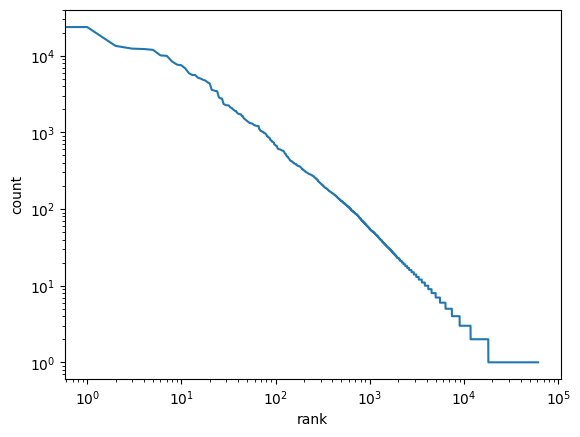

In [19]:
import matplotlib.pyplot as plt

plt.loglog([val for word, val in vocab_counter.most_common()])
plt.xlabel('rank')
plt.ylabel('count')

The plot shows that the distribution of the words in the vocabulary follows the Zipf's law. The most frequent word occurs approximately twice as often as the second most frequent word, three times as often as the third most frequent word, etc.

We can also filter the vocabulary by the frequency of the words. We will only consider the most frequent words and mark the rest as the `<unk>` token. Here we set the maximum vocabulary size to 50,000. But you can experiment with different sizes.

In [20]:
# prune vocabulary
max_vocab_size = 50000
vocab = vocab_counter.most_common(max_vocab_size)
# cast to list of words
vocab = [word for word, _ in vocab]
print(len(vocab))

50000


<a name='e4'></a>
### Exercise 4: Frequency of pairs of words
Calculate the frequency of (neighbouring) pairs of words in the training dataset.
1. (2p) List the most and least common pairs. Do the most common pairs make sense?
2. (2p) How many pairs occur only once in the dataset?
3. (2p) Plot the distribution of the pair frequencies.

Most common pairs:
[(('.', '.'), 7726), (("'", 's'), 4685), ((',', 'california'), 3340), (('️', '@'), 2966), (('️', '️'), 2242), (('&amp', ';'), 2019), (("'", 't'), 1806), (('los', 'angeles'), 1722), (('i', "'"), 1663), (('@', 'the'), 1621)]

Least common pairs:
[(('.', 'happylaborday'), 1), (('happylaborday', '@'), 1), (('@', 'beer'), 1), (('beer', 'nv'), 1), (('pizza', '('), 1), (('@', 'five50'), 1), (('five50', '-'), 1), (('mini', 'is'), 1), (('one', 'deserves'), 1), (('deserves', 'her'), 1)]
Pairs that occur only once: 194720


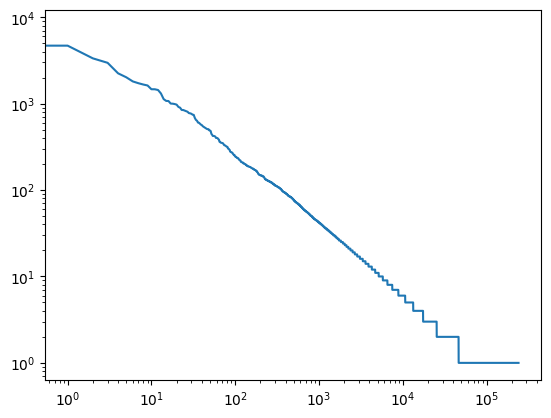

In [21]:
### YOUR CODE HERE
from collections import Counter

pair_counter = Counter()

for example in dataset['train']:
    tokens = example['text'].split()
    for i in range(len(tokens) - 1):
        pair = (tokens[i], tokens[i + 1])
        pair_counter[pair] += 1

# 1st question
print("Most common pairs:")
print(pair_counter.most_common(10))
print("\nLeast common pairs:")
print(pair_counter.most_common()[-10:])

# 2nd question
num_once = sum(1 for c in pair_counter.values() if c == 1)
print("Pairs that occur only once:", num_once)

# 3rd question
ffreqs = [count for _, count in pair_counter.most_common()]
plt.loglog(ffreqs)


--- YOUR ANSWERS HERE
1) The most common word pairs include combinations of frequent words and punctuation, such as pairs containing “the”/punctuation or common locations (“los angeles”). On the other hand the least common word pairs include unique combinations of words, which appear only once, such as names/hashtags/ etc. It does make sense given the social media text.
2) Pairs that occur only once: 194720
3) The distribution of bigram frequencies is highly skewed.

We will define and add three special tokens to our vocabulary:
- unknown token ```<unk>```, which will represent words outside our vocabulary;
- begining of sequence token ```<s>```, which will always be the first token of a sequence;
- end of sequence token ```</s>```, which will mark the end of the sequence and allow the model to finish generation.

In [22]:
unknown_token = '<unk>'
bos_token = '<s>'
eos_token = '</s>'
vocab.append(unknown_token)
vocab.append(bos_token)
vocab.append(eos_token)

### 2.3 Tokenize the dataset
The function below tokenizes the cleaned text (```example['clean']```) by splitting it on spaces. It replaces the words that are not in the vocabulary with the `<unk>` token.

<a name='e5'></a>
### Exercise 5: Tokenize the dataset
(4p) Fill in the function below to tokenize the dataset. The function will be applied to the dataset through the `map()` method, so it returns the updated example. Your task is to split the text by spaces and replace the words that are not in the vocabulary with the `<unk>` token. The tokenized sequence should start with the `bos_token` token and end with the 'eos_token'.

In [23]:
def tokenize(text, vocab, unknown_token='<unk>', bos_token='<s>', eos_token='</s>'):
    """
    Tokenizes the text that is assumed to be cleaned first with the clean() function. The tokenized sequence should start with the `bos_token` token and end with the 'eos_token'.
    Args:
        text: a cleaned text
        vocab: a vocabulary as a list of words
        unknown_token: a token to replace the words that are not in the vocabulary
    Returns: tokenized text as a list of tokens

    """

    tokens = []  # list of tokens, your code should fill this variable

    tokens.append(bos_token)
    for word in text.split():
        if word in vocab:
            tokens.append(word)
        else:
            tokens.append(unknown_token)
    tokens.append(eos_token)
    return tokens

Let's test the function:

In [24]:
tokenized = tokenize("what are you doing someunknowntoken ?", vocab, unknown_token, bos_token, eos_token)
print(tokenized)

assert tokenized[0] == bos_token, "First token should be bos_token"
assert tokenized[-1] == eos_token, "Last token should be eos_token"

['<s>', 'what', 'are', 'you', 'doing', '<unk>', '?', '</s>']


In [25]:
def tokenize_example(example, vocab, unknown_token='<unk>', bos_token='<s>', eos_token='</s>'):
    """
    Applies the tokenize() function to the example from the Dataset
    Args:
        example: an example from the Dataset
        vocab: a vocabulary as a list of words
        unknown_token: a token to replace the words that are not in the vocabulary
    Returns: update example containing 'tokens' column

    """
    text = example['text']
    tokens = tokenize(text, vocab, unknown_token, bos_token, eos_token)
    example['tokens'] = tokens
    return example


dataset = dataset.map(tokenize_example,
                      fn_kwargs={
                          'vocab': vocab,
                          'unknown_token': unknown_token,
                          'bos_token': bos_token,
                          'eos_token': eos_token,
                      }, desc="Tokenizing text")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'text_length', 'tokens'],
        num_rows: 45000
    })
    test: Dataset({
        features: ['text', 'label', 'text_length', 'tokens'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['text', 'label', 'text_length', 'tokens'],
        num_rows: 5000
    })
})


Let us examine several entries from the dataset. We can see that the `tokens` column has been added to each example.

In [26]:
for i in range(5):
    print('Original tweet:')
    print(dataset['train'][i]['text'])
    print('Tokenized tweet:')
    print(dataset['train'][i]['tokens'])

Original tweet:
sunday afternoon walking through venice in the sun with @user ️ ️ ️ @ abbot kinney , venice
Tokenized tweet:
['<s>', 'sunday', 'afternoon', 'walking', 'through', 'venice', 'in', 'the', 'sun', 'with', '@user', '️', '️', '️', '@', 'abbot', 'kinney', ',', 'venice', '</s>']
Original tweet:
time for some bbq and whiskey libations . chomp , belch , chomp ! ( @ lucille ' s smokehouse bar-b-que )
Tokenized tweet:
['<s>', 'time', 'for', 'some', 'bbq', 'and', 'whiskey', 'libations', '.', 'chomp', ',', 'belch', ',', 'chomp', '!', '(', '@', 'lucille', "'", 's', 'smokehouse', 'bar-b-que', ')', '</s>']
Original tweet:
love love love all these people ️ ️ ️ friends bff celebrate blessed sundayfunday @ san…
Tokenized tweet:
['<s>', 'love', 'love', 'love', 'all', 'these', 'people', '️', '️', '️', 'friends', 'bff', 'celebrate', 'blessed', 'sundayfunday', '@', 'san…', '</s>']
Original tweet:
️ ️ ️ ️ @ toys " r " us
Tokenized tweet:
['<s>', '️', '️', '️', '️', '@', 'toys', '"', 'r', '"', 'u

Make sure that the tokenization works as you intended. If not, revisit the cleaning and tokenization functions.

<a name='e6'></a>
### Exercise 6: Questions about the tokenization
1. (1p) How many unknown tokens are in the validation dataset after tokenization?
2. (1p) What is the distribution of the number of tokens in the training dataset?
3. (1p) How the number of tokens corresponds to the number of characters in our dataset?
4. (1p) How the size of the vocabulary (```max_vocab_size```) affects the number of unknown tokens?
5. (1p) How does the size of the vocabulary affect the number of tokens in the dataset?
6. (1p) Think about the advantages and disadvantages of the tokenization method we used. What are the cases when it will not work well?
7. (1p) Decide what vocabulary size you will use for the rest of the lab. It shouldn't be smaller than 10,000. Give a short explanation.

1) UNK tokens in validation: 5727


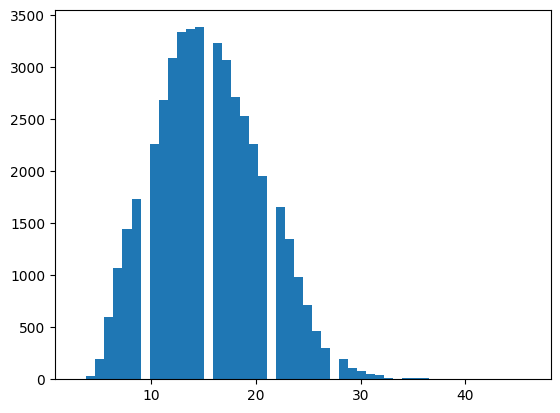

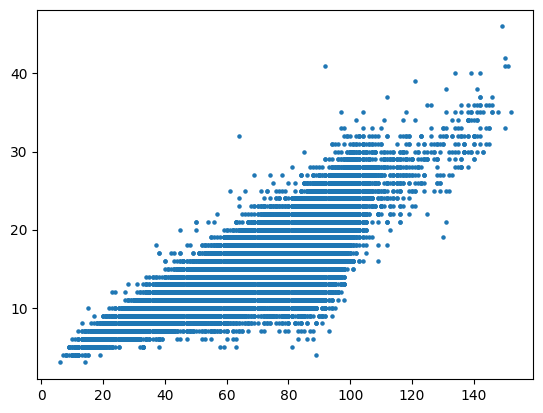

In [27]:
### YOUR CODE HERE
# 1st question
unk_count = sum(
    tok == "<unk>"
    for ex in dataset["validation"]
    for tok in ex["tokens"]
)
print("1) UNK tokens in validation:", unk_count)
# 2nd question
token_lengths = [len(ex["tokens"]) for ex in dataset["train"]]
plt.hist(token_lengths, bins=50)
plt.show()
# 3rd question
char_lengths = [len(ex["text"]) for ex in dataset["train"]]
plt.scatter(char_lengths, token_lengths, s=5)
plt.show()



--- YOUR ANSWERS HERE
1) The number of unknown tokens in the validation dataset after tokenization is 5727
2) The distribution of the number of tokens in the training dataset is right skewed
3) The number of tokens is positively correlated with the number of characters in the dataset. Sentences with more characters generally contain more tokens.
4) Increasing the vocabulary size reduces the number of unknown tokens since more words're included in the vocabulary. A smaller vocabulary leads to more words being unknown.
5) The size of the vocabulary doesn't affect the total number of tokens in the dataset but it changes how many tokens are mapped to <unk>.
6) The main advantage is that it's easy to implement. However it doesn't handle rare words, misspellings,morphological variations well since all unseen words are mapped to <unk>. This can lead to information loss especially in informal text such as social media text
7) A vocabulary size of 50000. This size provides a good balance between vocabulary coverage and the number of unknown tokens.

## 3. N-grams

<a name='e7'></a>
### Exercise 7: Counting unigrams

(4p) Fill in the function below. Iterate through the dataset and count the tokens (unigrams). Check the documentation of the `Counter` dictionary (https://docs.python.org/3/library/collections.html#collections.Counter).

In [28]:
def calculate_unigrams(dataset):
    """
        Iterates through a dataset to count the frequency of individual tokens (unigrams).

        Args:
            dataset: a dataset where each example is a dictionary containing a 'tokens' key with
                a list of strings.

        Returns: a counter object mapping each unique token to its total number of occurrences across the entire dataset.
    """
    unigrams_counter = Counter()
    for example in tqdm.tqdm(dataset):
        ### YOUR CODE HERE
        unigrams_counter.update(example["tokens"])
        ### YOUR CODE ENDS HERE
    return unigrams_counter


In [29]:
unigrams = calculate_unigrams(dataset['train'])
print(unigrams.most_common(10))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 57270.65it/s]

[('<s>', 45000), ('</s>', 45000), ('@', 24206), ('.', 23674), ('the', 13446), (',', 12383), ('@user', 12236), ('!', 11938), ('<unk>', 11137), ("'", 10108)]


<a name='e8'></a>
### Exercise 8: Counting n-grams (with n > 1)
(4p) Fill in the following function. It should iterate through the dataset and count the n-grams of the order `n` (a parameter).

In [30]:
def calculate_ngrams(dataset, n):
    """
    Iterates through the dataset to count the occurrences of n-gram contexts.

    Args:
        dataset: a dataset object where each example contains a 'tokens' key (a list of strings).
        n: the order of the n-gram model.

    Returns: a counter object mapping n-gram tuples to their frequency in the dataset.
    """
    ngrams_counter = Counter()
    for example in tqdm.tqdm(dataset):
        ### YOUR CODE HERE
        tokens = example["tokens"]
        for i in range(len(tokens) - n + 1):
            ngram = tuple(tokens[i:i+n])
            ngrams_counter[ngram] += 1
        ### YOUR CODE ENDS HERE
    return ngrams_counter

In [31]:
bigrams = calculate_ngrams(dataset['train'], n=2)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 45863.94it/s]


<a name='e9'></a>
### Exercise 9: Examining n-grams
Count the higher-rank n-grams.
1. (1p) Check the most common n-grams of each rank.
2. (3p) Plot the number of n-grams dependent on the rank n.

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 56680.84it/s]



Top 3 for n=1:
<s> -> 45000
</s> -> 45000
@ -> 24206


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 48463.23it/s]



Top 3 for n=2:
('.', '.') -> 7726
("'", 's') -> 4685
('california', '</s>') -> 3376


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 47455.69it/s]


...


Top 3 for n=4:
('.', '.', '.', '.') -> 1184
('@', 'los', 'angeles', ',') -> 844
('los', 'angeles', ',', 'california') -> 797


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 49398.76it/s]



Top 3 for n=5:
('los', 'angeles', ',', 'california', '</s>') -> 792
('@', 'los', 'angeles', ',', 'california') -> 789
('.', '.', '.', '.', '.') -> 495


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45000/45000 [00:00<00:00, 49007.61it/s]


Top 3 for n=6:
('@', 'los', 'angeles', ',', 'california', '</s>') -> 786
('.', '.', '.', '.', '.', '.') -> 242
('@', 'san', 'francisco', ',', 'california', '</s>') -> 198


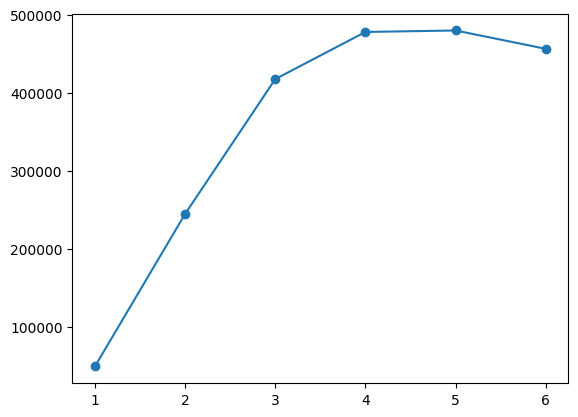

In [32]:
### YOUR CODE HERE
max_n = 6
ngram_counters = {}
unique_counts = []
ns = list(range(1, max_n + 1))
for n in ns:
    if n == 1:
        counter = calculate_unigrams(dataset["train"])
    else:
        counter = calculate_ngrams(dataset["train"], n=n)
    ngram_counters[n] = counter
    unique_counts.append(len(counter))
    print(f"\nTop 3 for n={n}:")
    for gram, cnt in counter.most_common(3):
        print(gram, "->", cnt)
plt.plot(ns, unique_counts, marker="o")
plt.show()


1 The most common unigram is <s>, bigram - ('.', '.'), trigram - ('.', '.', '.'), 4-gram - ('.', '.', '.', '.'), 5-gram -('los', 'angeles', ',', 'california', '</s>') , 6-gram - ('@', 'los', 'angeles', ',', 'california', '</s>') 
2 The plot shows that when n=1 number of unique uniqrams is quite small since its just size of vocabulary, when n=2,3,4,5 the number of unique n-grams growth really fast, but the numer of unique 6-grams is smaller then number of unique 5- grams and this happens because long word sequences rarely repeat, so the number of unique n-grams stops growing.

Having n-grams as Counters is nice, but for generation and calculating perplexity (coming up next) this would be inefficient. For this reason, we will create a class representing language models that are based on n-grams. You can check a quick guide on Object Oriented Programming (OOP) in Python here https://www.geeksforgeeks.org/python/python-oops-concepts/

Currently, we have the counts of n-grams. The main problem is that, for generation, we need the counts of each token in the vocabulary GIVEN the previous (n-1) tokens. If we were to leave the n-gram Counter as is, we would have to iterate over each entry and check if the first (n-1) tokens matches what we have already generated. To mitigate this issue, we will create a dictionary of Counters, where keys will be the tuples with (n-1) n-grams. This allows us to simply retrieve the appropriate counter.

We are also start using numpy, which is a very potent and prolific library for matrices and their manipulations. It is highly optimized, so it will make our code run faster. You can check the documentation here https://numpy.org/doc/stable/

<a name='e10'></a>
### Exercise 10: N-gram Language Model class
Fill in the two methods in NgramLanguageModel class:
 1. (3p) `build_model()` builds the model, which is a `dictionary` of `Counters`. The keys of this dictionary are the tokens of the n-grams without the last token. The values of the dictionary are separate `Counters` of the final tokens. For example, in case of the tri-grams `("at", "the","university")` with count 3 and `("at", "the","party")` with count 2, the previous tokens for both is a bi-gram `("at", "the")`. The resulting `Counter` for this bi-gram is `{"university": 3, "party": 2}`.
 2. (3p) `get_counts()` returns a numpy array with counts of all vocab tokens given the passed previous tokens. This function operates on the indices of tokens in the vocabulary. The fastest way to get the index of a token is to use the `self.word_to_index` dictionary. It will return the index of the token: `self.word_to_index[token]`.

In [33]:
class NgramLanguageModel:
    """
    A dictionary-based N-gram Language Model.

    Attributes:
        vocab: a list of unique tokens in the language.
        word_to_index: the apping from token strings to their integer indices.
        vocab_size: total number of unique tokens in the vocabulary.
        ngrams: a counter of n-gram tuples.
        n: the order of the n-gram model
        model (dict): a nested dictionary where keys are context tuples and values are Counters of following tokens.
    """
    def __init__(self, ngrams, n, vocab):
        self.vocab = vocab
        self.word_to_index = {word: i for i, word in enumerate(self.vocab)}
        self.vocab_size = len(vocab)
        self.ngrams = ngrams
        self.n = n
        self.model = self.build_model()

    def build_model(self):
        """
        Converts flat n-gram counts into a nested dictionary structure for efficiency.

        Returns:a dictionary where: key: tuple (the context of length n-1), value: collections.Counter (counts of tokens following that context)
        """
        model = {}
        for ngram, count in tqdm.tqdm(self.ngrams.items()):
            ### YOUR CODE HERE
            context = tuple(ngram[:-1])      
            next_token = ngram[-1]           
            if context not in model:
                model[context] = Counter() 
            
            model[context][next_token] += count  

            ### YOUR CODE ENDS HERE
        return model

    def get_counts(self, previous_tokens):
        """
        Retrieves the counts of all vocabulary tokens that follow a given context. Only the last (n-1) tokens are used as the context.

        Args:
            previous_tokens: the sequence of tokens seen so far.

        Returns: an integer np.ndarray of shape (vocab_size,) where the value at index 'i' is the count of vocab[i] following the context.
        """
        previous_tokens = tuple(previous_tokens[-(self.n - 1):])
        counts = np.zeros(self.vocab_size, dtype=int)
        ### YOUR CODE ENDS HERE
        if previous_tokens not in self.model:
            return counts
        next_counter = self.model[previous_tokens]
        for token, cnt in next_counter.items():
            idx = self.word_to_index[token]
            counts[idx] = cnt
        ### YOUR CODE ENDS HERE
        return counts

Let us test this class on a toy example

In [34]:
toy_trigrams = Counter({
    ("at", "the", "university"): 3,
    ("at", "the", "party"): 2,
    ("feed", "the", "cat"): 1,
    ("feed", "the", "dog"): 4,
})

toy_vocab = ["at", "the", "university", "party", "feed", "cat", "dog"]

toy_lm = NgramLanguageModel(toy_trigrams, 3, toy_vocab)
print('model', toy_lm.model)

counts = toy_lm.get_counts(("at", "the"))
print('counts', counts)

assert type(counts) == np.ndarray, "counts should be a numpy array"
assert counts.size == len(toy_vocab)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 143395.01it/s]

model {('at', 'the'): Counter({'university': 3, 'party': 2}), ('feed', 'the'): Counter({'dog': 4, 'cat': 1})}
counts [0 0 3 2 0 0 0]


The `toy_lm.model` should be something like this:

```
{
    ('at', 'the'): Counter({
        'university': 3,
        'party': 2
    }),
    ('feed', 'the'): Counter({
        'dog': 4,
        'cat': 1
    })
}
```

The `counts` should be:
```
[0 0 3 2 0 0 0]
```

Now, we can create our bi-gram language model

In [35]:
bigram_lm = NgramLanguageModel(bigrams, 2, vocab)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 245178/245178 [00:00<00:00, 2182306.99it/s]


<a name='e11'></a>
### Exercise 11: Greedy Generate
(4p) Implement the following greedy generation function. It should first call the model object (passed as a parameter) to obtain the counts of each token in our vocabulary given the already generated sequence. Next, it should select the token with the highest count and append it to the already generated sequence. You might find `numpy.argmax()` function handy (https://numpy.org/doc/stable/reference/generated/numpy.argmax.html).

In [36]:
def greedy_generate(language_model, max_tokens, bos_token, eos_token, previous_tokens=None):
    generated = [bos_token] if previous_tokens is None else previous_tokens
    while generated[-1] != eos_token and len(generated) < max_tokens:
        ### YOUR CODE ENDS HERE
        counts = language_model.get_counts(generated)
        next_index = int(np.argmax(counts))
        next_token = language_model.vocab[next_index]
        generated.append(next_token)
        ### YOUR CODE ENDS HERE
             
    return generated

Let's test the generations starting with the empty sequence and with "you can...".

In [37]:
generated = greedy_generate(bigram_lm, 15, bos_token, eos_token)
print(generated)

generated = greedy_generate(bigram_lm, 15, bos_token, eos_token, previous_tokens=["<s>", "you", "can"])
print(generated)

['<s>', 'i', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the', 'best']
['<s>', 'you', 'can', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the']


<a name='e12'></a>
### Exercise 12: Sampling Generate
(4p) Implement the sampling generation function. It is similar to the previous one, but the selection of the next tokens should be random, with the probabilities based on the counts returned by the model. Make sure you take care of the case where the n-gram was not encountered (meaning that the model will return all counts equal to zero). Check `numpy.random` package for the appropriate function to sample the tokens with respect to their probabilities (https://numpy.org/doc/2.4/reference/random/legacy.html).

In [38]:
def sampling_generate(language_model, max_tokens, bos_token, eos_token, previous_tokens=None):
    generated = [bos_token] if previous_tokens is None else previous_tokens

    ### YOUR CODE ENDS HERE
    while generated[-1] != eos_token and len(generated) < max_tokens:
        counts = language_model.get_counts(generated)
        total = counts.sum()

        if total == 0:
            generated.append(eos_token)
            break

        probs = counts / total
        next_index = int(np.random.choice(len(probs), p=probs))
        next_token = language_model.vocab[next_index]
        generated.append(next_token)


    ### YOUR CODE ENDS HERE

    return generated

Let's test the function:

In [39]:
generated = sampling_generate(bigram_lm, 15, bos_token, eos_token)
print(generated)

generated = sampling_generate(bigram_lm, 15, bos_token, eos_token, previous_tokens=["<s>", "you", "can"])
print(generated)

['<s>', 'feedme', 'was', 'so', 'special', 'thanks', 'gorgeous', 'view', 'from', 'glast_shop', '@', 'staples', 'center', '</s>']
['<s>', 'you', 'can', "'", 's', 'hair', 'by', 'tiana', 'renee', '</s>']


<a name='e13'></a>
### Exercise 13: Smoothing

(4p) In this exercise you will add smoothing to the generation. Smoothing parameter $\alpha$ is controlled by the parameter `smoothing` with a default value of `1` (too high, as you will see in the next exercises). Consult the lecture slides for the formulation.

In [40]:
def sampling_generate_smoothing(language_model, max_tokens, bos_token, eos_token, smoothing=1,
                                previous_tokens=None):
    generated = [bos_token] if previous_tokens is None else previous_tokens
    ### YOUR CODE ENDS HERE
    
    while generated[-1] != eos_token and len(generated) < max_tokens:
        counts = language_model.get_counts(generated)
        counts = counts + smoothing
        probs = counts / counts.sum()
        next_index = np.random.choice(len(probs), p=probs)
        next_token = language_model.vocab[next_index]
        generated.append(next_token)


    ### YOUR CODE ENDS HERE
    return generated

In [41]:
generated = sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=1)
print(generated)

generated = sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=1,
                                        previous_tokens=["<s>", "you", "can"])
print(generated)

['<s>', 'throw', 'sweetdreamsbyrg', 'parents', 'hyper', 'speed', 'gangrelated', 'travel', 'jeffbussephotography', 'khloé', 'pos', 'getty', 'trou', 'jinglebellsonmyears', 'kehodges29']
['<s>', 'you', 'can', 'shessochubby', 'montecito', 'familyholiday', 'grown…', 'physically', '스냅챗', 'dwe', 'lax', 'botanicaworkshop', 'fans', 'grill…', 'secondjobletsgo']


<a name='e14'></a>
### Exercise 14: Qualitative Analysis of Generations
1. (2p) Examine the generations of the functions above (greedy, sampling and sampling with smoothing). Make sure to experiment with different values of smoothing. Generate at least 5 examples for each function and smoothing value.
2. (2p) Do the same as above but start with a sequence of tokens (for example `["<s>", "you", "can"]`) Try at least 3 starting sequences.

In [42]:
### YOUR CODE HERE
#1
print("\nGreedy")

for i in range(5):
    print(greedy_generate(bigram_lm, 15, bos_token, eos_token))

print("\nSampling")
for i in range(5):
    print(sampling_generate(bigram_lm, 15, bos_token, eos_token))

print("\nSampling and smoothing 0.1")
for i in range(5):
    print(sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=0.1))
print("\nSampling and smoothing 0.2")
for i in range(5):
    print(sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=0.2))
print("\nSampling and smoothing 0.3")
for i in range(5):
    print(sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=0.3))
print("\nSampling and smoothing 0.5")
for i in range(5):
    print(sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=0.5))
print("\nSampling and smoothing 2")
for i in range(5):
    print(sampling_generate_smoothing(bigram_lm, 15, bos_token, eos_token, smoothing=2))

#2
start_sequences = [
    ["<s>", "you", "can"],
    ["<s>", "what", "is"],
    ["<s>", "we", "can"]
]

for start in start_sequences:
    print("\nStarting sequence:", start)

    print("\nGreedy:")
    for i in range(5):
        print(greedy_generate(bigram_lm, 15, bos_token, eos_token, previous_tokens=start.copy()))

    print("\nSampling:")
    for i in range(5):
        print(sampling_generate(bigram_lm, 15, bos_token, eos_token, previous_tokens=start.copy()))

    print("\nSampling + smoothing (1):")
    for i in range(5):
        print(sampling_generate_smoothing(
            bigram_lm, 15, bos_token, eos_token,
            smoothing=1,
            previous_tokens=start.copy()
        ))



Greedy
['<s>', 'i', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the', 'best']
['<s>', 'i', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the', 'best']
['<s>', 'i', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the', 'best']
['<s>', 'i', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the', 'best']
['<s>', 'i', "'", 's', 'a', 'great', 'time', 'with', 'my', 'favorite', 'people', '!', '@', 'the', 'best']

Sampling
['<s>', 'merry', 'christmas', 'play', 'me', 'think', 'i', '(', '@user', '</s>']
['<s>', 'said', 'you', 'my', 'friends', 'are', 'the…', '</s>']
['<s>', 'art', 'art…', '</s>']
['<s>', 'lauryn', 'hill', '(', 'link', 'in', 'life', 'but', 'this', 'cute', '!', 'legdayz', 'feeltheburn', '@', 'disneyland']
['<s>', 'la', 'photo', 'svrbtz', 'skateboarding', '@user', '@', 'downtown', 'truckee', 'sunday', "'", 'm', 'home', '️', '@']

Sampling and smoothing 0.1

--- YOUR ANSWERS HERE
1
In exercise 1 we can see that greedy generation always produces the same sentence since it always chooses the most common word, Sampling produces sentences that doesn't make any sense because it randomly chooses the next word based on its probability.
When we combine sampling and smoothing the text becomes even more random and meaningless because smoothing prevents zero probabilities and makes sampling even more diverse

2
In exercise 1 we can see that greedy generation always produces the same sentence even if we start with a fixed sequence of tokens, since it always chooses the most common word.
Sampling chooses the next word randomly based on probabilities and because of that, the sentences are different each time even if we start with the same tokens
When we use ampling with smoothing, rare words also get a chance to be selected, so the sentences contain many usernames, hashtags, numbers, and unusual tokens.




## 4. Perplexity

In this section, we will implement and use perplexity as the metric that will help us judge which language model is the best. For this we will first calculate probabilities of each token in a sequence, depending on the previous tokens. For numerical stability, we will actually use logarithms of probabilities.

<a name='e15'></a>
### Exercise 15: Calculate sequence probabilities

(4p) Fill the following function to calculate the logarithms of probabilities of each token in a sequence of tokens. Apply smoothing when calculating the probability. You can first calculate the probability (with smoothing) and then apply `numpy.log()` function.

In [43]:
def calculate_total_logprob_smoothing(tokens, language_model, smoothing=0.0):
    logprobs = np.zeros(len(tokens), dtype=float)
    for i in range(0, len(tokens)):
        previous_tokens = tokens[:i]
        current_token = tokens[i]
        ### YOUR CODE ENDS HERE
        counts = language_model.get_counts(previous_tokens)
        total = counts.sum()
        V = language_model.vocab_size
        idx = language_model.word_to_index[current_token]
        prob = (counts[idx] + smoothing) / (total + smoothing * V)
        logprobs[i] = np.log(prob)
        ### YOUR CODE ENDS HERE
    total_logprob = logprobs.sum()
    return total_logprob

<a name='e16'></a>
### Exercise 16: Calculate sentence perplexity

(4p) In this exercise, you will use the function above to calculate the perplexity. Consult the slides for the formulation that depends on the logarithm of probability.

In [6]:
def calculate_perplexity(tokens, languge_model, smoothing=0.0):
    total_logprob = calculate_total_logprob_smoothing(tokens, languge_model, smoothing)
    ### YOUR CODE ENDS HERE
    N = len(tokens)
    perplexity = np.exp(- total_logprob / N)
    ### YOUR CODE ENDS HERE
    return perplexity

We can test our function:

In [45]:
tokens = dataset['train'][0]['tokens']
print(tokens)

perplexity = calculate_perplexity(tokens, bigram_lm, smoothing=1.0)
print(perplexity)

['<s>', 'sunday', 'afternoon', 'walking', 'through', 'venice', 'in', 'the', 'sun', 'with', '@user', '️', '️', '️', '@', 'abbot', 'kinney', ',', 'venice', '</s>']
1559.2840036344078


<a name='e17'></a>
### Exercise 17: Perplexity of sentences
(4p) Calculate perplexities of several (at least 5) sentences of your choice. Try different values of smoothing. Discuss the results: do the perplexities align with what you expected?

In [5]:
### YOUR CODE HERE
sentences = [
    "sunday afternoon walking through venice",
    "i really like to walk in the sun",
    "Every morning i start preparing for NLP exam mentally",
    "Sentence with crazy letters sdpofkodjjfovj sodjovfjojdfo",
    "Merry Christmas! With you luck and best wishes @your friend"
]

smoothings = [0.0, 0.0001, 0.1, 0.3, 0.5, 0.7, 1.0]

for s in sentences:
    cleaned = clean(s)
    tokens = tokenize(cleaned, bigram_lm.vocab)

    print("Sentence:", s)
    print("Tokens:", tokens)

    for a in smoothings:
        pp = calculate_perplexity(tokens, bigram_lm, smoothing=a)
        print(f"  smoothing={a}: perplexity={pp}")

    

NameError: name 'clean' is not defined

--- YOUR ANSWERS HERE
1 and 2) The perplexities and their values do align with what was expected. All of the words are in the dataset and the sentences are very simple, the bigrams were 100% in the training set, then the model has lower perplexity with lower smoothing values.
3) The perplexity is huge due to the very rare words used in the sentence, the values do align with what was exprected.
4) In this sentence the results are way more interesting, as it contains several unk tokens, the bigrams at smoothing = 0.0001 received very small probabilities near zero, therefore the perplexity value is big. At 0.3 the value is the smallest.
5) Most of the bigrams are common and for sure are in the training set, then when we increase the smoothing we decrease the probability of this bigrams to be chosen, and as a result the perplexity is bigger

<a name='e18'></a>
### Exercise 18: Perplexity of the whole dataset

(4p) Now we will calculate the perplexity of the entire dataset (or a subset). The function you will implement should calculate the logarithms of probabilities and the lengths of each of the sequences in the dataset. We need both to correctly calculate the perplexity per token.

In [47]:
def calculate_perplexity_dataset(dataset, languge_model, smoothing=0.0):
    all_logprobs = []
    all_lengths = []
    ### YOUR CODE ENDS HERE
    for item in tqdm.tqdm(dataset):
        tokens = item["tokens"]
        total_logprob = calculate_total_logprob_smoothing(tokens, languge_model, smoothing)

        all_logprobs.append(total_logprob)
        all_lengths.append(len(tokens))

    total_logprob = np.sum(all_logprobs)
    total_length = np.sum(all_lengths)

    perplexity = np.exp(- total_logprob / total_length)
    ### YOUR CODE ENDS HERE
    return perplexity


Now, let's calculate the perplexity of the validation dataset.

In [48]:
validation_perplexity = calculate_perplexity_dataset(dataset['validation'], bigram_lm, smoothing=1.0)
print('validation perplexity', validation_perplexity)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 474.38it/s]

validation perplexity 3672.9770793210564


## 5. Comparing Language Models
In this final section, you will use all of the above to evaluate different models against each other. While this is a single exercise, you are expected add as many code and markdown cells as you wish. You can plot the results, add tables, etc.

The models should be evaluated on the `test` subset of the dataset. None of the models should have "seen" it during training and any hyperparameter tuning (if applicable). Below, you can see how we can use our function `calculate_perplexity_dataset()` to calculate the perplexity:

In [49]:
unigram = calculate_ngrams(dataset['train'], n=1)
unigram_lm = NgramLanguageModel(unigram, 1, vocab)
test_perplexity = calculate_perplexity_dataset(dataset['test'], unigram_lm, smoothing=1.0)
print('test perplexity', test_perplexity)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [03:18<00:00, 252.11it/s]

test perplexity 30125.041736094317


In [50]:
test_perplexity = calculate_perplexity_dataset(dataset['test'], bigram_lm, smoothing=1.0)
print('test perplexity', test_perplexity)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [02:02<00:00, 407.35it/s]

test perplexity 3540.17726601039


In [51]:
test_perplexity = calculate_perplexity_dataset(dataset['test'], bigram_lm, smoothing=1.0)
print('test perplexity', test_perplexity)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [01:44<00:00, 477.59it/s]

test perplexity 3540.17726601039


In [52]:
trigram = calculate_ngrams(dataset['train'], n= 3)
trigram_lm = NgramLanguageModel(trigram, 3, vocab)
test_perplexity = calculate_perplexity_dataset(dataset['test'], trigram_lm, smoothing=1.0)
print('test perplexity', test_perplexity)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:13<00:00, 3598.98it/s]

test perplexity 20456.28159937651


In [53]:
fourgram = calculate_ngrams(dataset['train'], n= 4)
fourgram_lm = NgramLanguageModel(trigram, 4, vocab)
test_perplexity = calculate_perplexity_dataset(dataset['test'], fourgram_lm, smoothing=1.0)
print('test perplexity', test_perplexity)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:08<00:00, 6101.84it/s]

test perplexity 45304.00986130164


In [54]:
tengram = calculate_ngrams(dataset['train'], n= 10)
tengram_lm = NgramLanguageModel(trigram, 10, vocab)
test_perplexity10 = calculate_perplexity_dataset(dataset['test'], tengram_lm, smoothing=1.0)
print('test perplexity', test_perplexity)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:08<00:00, 6069.30it/s]

test perplexity 45304.00986130164


This could take couple of minutes. To test your code you can select a subset of this dataset. But make sure to report the final results in the exercise below on the full test set.

In [56]:
test_1000_perplexity1 = calculate_perplexity_dataset(dataset['test'].select(range(1000)), unigram_lm, smoothing=1.0)
print('test (1000 examples) perplexity', test_1000_perplexity1)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 252.38it/s]

test (1000 examples) perplexity 30184.045603167233


In [59]:
test_1000_perplexity2 = calculate_perplexity_dataset(dataset['test'].select(range(1000)), bigram_lm, smoothing=1.0)
print('test (1000 examples) perplexity', test_1000_perplexity2)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 448.18it/s]

test (1000 examples) perplexity 3452.471486296915


In [60]:
#SMOOTHING 1.0
test_1000_perplexity3 = calculate_perplexity_dataset(dataset['test'].select(range(1000)), trigram_lm, smoothing=1.0)
print('test (1000 examples) perplexity', test_1000_perplexity3)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3121.15it/s]

test (1000 examples) perplexity 19569.156472677798


In [62]:
test_1000_perplexity4 = calculate_perplexity_dataset(dataset['test'].select(range(1000)), fourgram_lm, smoothing=1.0)
print('test (1000 examples) perplexity', test_1000_perplexity4)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4885.94it/s]

test (1000 examples) perplexity 45331.25338239235


In [64]:
#SMOOTHING 0.001
test_1000_perplexity_1small = calculate_perplexity_dataset(dataset['test'].select(range(1000)), unigram_lm, smoothing=0.001)
print('test (1000 examples) perplexity', test_1000_perplexity_1small)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 256.38it/s]

test (1000 examples) perplexity 30053.664053310786


In [65]:
test_1000_perplexity_2small = calculate_perplexity_dataset(dataset['test'].select(range(1000)), bigram_lm, smoothing=0.001)
print('test (1000 examples) perplexity', test_1000_perplexity_2small)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 449.60it/s]

test (1000 examples) perplexity 723.3749904348604


In [66]:
test_1000_perplexity_4small = calculate_perplexity_dataset(dataset['test'].select(range(1000)), fourgram_lm, smoothing=0.001)
print('test (1000 examples) perplexity', test_1000_perplexity_4small)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4922.78it/s]

test (1000 examples) perplexity 38882.366415507706


In [67]:
test_1000_perplexity_3small = calculate_perplexity_dataset(dataset['test'].select(range(1000)), trigram_lm, smoothing=0.001)
print('test (1000 examples) perplexity', test_1000_perplexity_3small)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2959.48it/s]

test (1000 examples) perplexity 4404.482744527498


In [68]:
resultsbig = {"Model": ['unigram', 'bigram', 'trigram', 'fourgram'],
              "Perplexity test(1.0)": [test_1000_perplexity1, test_1000_perplexity2, test_1000_perplexity3, test_1000_perplexity4],
              "Perplexity test(0.001)": [test_1000_perplexity_1small, test_1000_perplexity_2small, test_1000_perplexity_3small, test_1000_perplexity_4small]}
df = pd.DataFrame(resultsbig)
df

,Model,Perplexity test(1.0),Perplexity test(0.001)
0,unigram,30184.045603,30053.664053
1,bigram,3452.471486,723.374990
2,trigram,19569.156473,4404.482745
3,fourgram,45331.253382,38882.366416


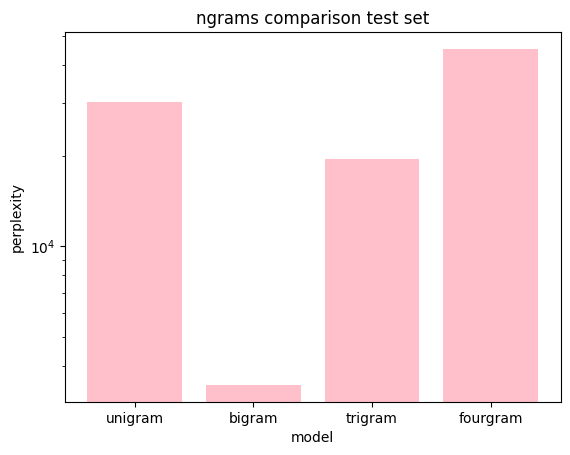

In [69]:
models = ["unigram", "bigram", "trigram", "fourgram"]
pps = [test_1000_perplexity1, test_1000_perplexity2, test_1000_perplexity3, test_1000_perplexity4]

plt.figure()
plt.bar(models, pps)
plt.bar(models, pps, color="pink")
plt.yscale("log")
plt.xlabel("model")
plt.ylabel("perplexity")
plt.title("ngrams comparison test set")
plt.show()

<a name='e19'></a>
### Exercise 19: More Advanced Language Model
(20p) In this exercise, implement either an interpolation or backoff language model that combines more than one n-gram counter.
Make sure to adjust weights based on the perplexity of the validation dataset.
Compare the tuned model with previous models on the test set. Include n-grams with different values of n.
Discuss the results.

#### Requirements:
- create n-gram language models with higher values of n,
- implement at least one more advanced (combining multiple n-grams) language model,
- tune its weights on the `validation` subset,
- compare the model(s) against the basic models,
- discuss the results (Are the results as expected? Why? Why not? etc.)

In [80]:
class InterpolationLanguageModel:
    def __init__ (self, models, weights, smoothing=1.0):
        self.models = models
        self.weights = np.array(weights, dtype=float)
        self.smoothing = float(smoothing)

        self.vocab = models[0].vocab
        self.word_to_index = models[0].word_to_index
        self.vocab_size = models[0].vocab_size
    def _smoothed_probs_for_model(self, model, previous_tokens):
        counts = model.get_counts(previous_tokens).astype(float)
        total = counts.sum()
        V = self.vocab_size
        a = self.smoothing
        probs = (counts + a) / (total + a * V)
        return probs

    def get_counts(self, previous_tokens):
        probs = np.zeros(self.vocab_size, dtype=float)
        for w, m in zip(self.weights, self.models):
            probs += w * self._smoothed_probs_for_model(m, previous_tokens)
        return probs
    

In [81]:
def tune_interpolation_weights(validation_dataset, models, smoothing=1.0, step=0.25):
    best_pp = float("inf")
    best_weights = None

    grid = np.arange(0.0, 1.0 + 1e-9, step)

    for l1 in grid:
        for l2 in grid:
            l3 = 1.0 - l1 - l2
            if l3 < 0:
                continue

            weights = [l1, l2, l3]
            lm = InterpolationLanguageModel(models, weights, smoothing=smoothing)
            pp = calculate_perplexity_dataset(validation_dataset, lm, smoothing=0.0)

            if pp < best_pp:
                best_pp = pp
                best_weights = weights

    return best_weights, best_pp


In [84]:
models = [unigram_lm, bigram_lm, trigram_lm]

#choosing weights on reduced validation set, othwerwise it takes a lot of time
val_small = dataset["validation"].select(range(1000))

best_w, best_val_pp = tune_interpolation_weights(
    val_small,
    models=models,
    smoothing=1.0,
    step=0.25
)

print("Best weights (unigram, bigram, trigram):", best_w)
print("Validation set perplexity:", best_val_pp)
#interpolation model itself
interp_lm = InterpolationLanguageModel(models, best_w, smoothing=1.0)

#perplexity on test set
test_pp_interp = calculate_perplexity_dataset(dataset["test"], interp_lm, smoothing=0.0)
print(test_pp_interp)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 65.70it/s]


Best weights (unigram, bigram, trigram): [np.float64(0.25), np.float64(0.75), np.float64(0.0)]
Validation set perplexity: 2813.4198902992707


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [13:18<00:00, 62.60it/s]

2763.0916964714897


In [3]:
models = [unigram_lm, bigram_lm, trigram_lm]

#choosing weights on reduced validation set, othwerwise it takes a lot of time
val_small = dataset["validation"].select(range(1000))

best_w, best_val_pp = tune_interpolation_weights(
    val_small,
    models=models,
    smoothing=0.001,
    step=0.25
)

print("Best weights (unigram, bigram, trigram):", best_w)
print("Validation set perplexity:", best_val_pp)
#interpolation model itself
interp_lm = InterpolationLanguageModel(models, best_w, smoothing=0.001)

#perplexity on test set
test_pp_interp = calculate_perplexity_dataset(dataset["test"], interp_lm, smoothing=0.0)
print(test_pp_interp)


NameError: name 'unigram_lm' is not defined

In [ ]:
models = ["unigram", "bigram", "trigram", "fourgram", "interpolation model"]
pps = [test_1000_perplexity_1small, test_1000_perplexity_2small, test_1000_perplexity_3small, test_1000_perplexity_4small, test_pp_interp2]

plt.figure()
plt.bar(models, pps)
plt.bar(models, pps, color="pink")
plt.yscale("log")
plt.xlabel("model")
plt.ylabel("perplexity")
plt.title("model comparison test set(smoothing = 0.001)")
plt.show()

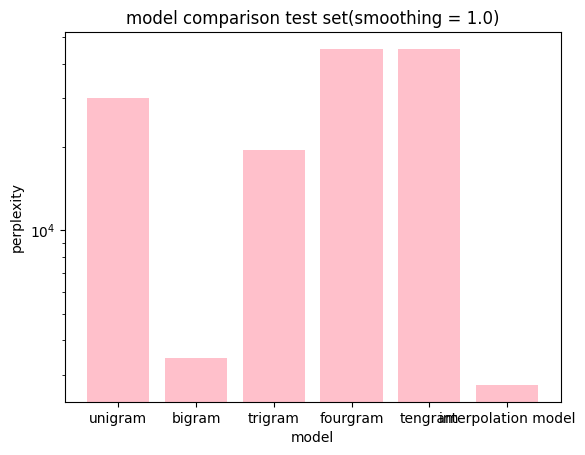

In [85]:
models = ["unigram", "bigram", "trigram", "fourgram", "tengram", "interpolation model"]
pps = [test_1000_perplexity1, test_1000_perplexity2, test_1000_perplexity3, test_1000_perplexity4, test_perplexity10, test_pp_interp]

plt.figure()
plt.bar(models, pps)
plt.bar(models, pps, color="pink")
plt.yscale("log")
plt.xlabel("model")
plt.ylabel("perplexity")
plt.title("model comparison test set(smoothing = 1.0)")
plt.show()


In [87]:
models = [unigram_lm, bigram_lm, trigram_lm]

#choosing weights on reduced validation set, othwerwise it takes a lot of time
val_small = dataset["validation"].select(range(1000))

best_w, best_val_pp = tune_interpolation_weights(
    val_small,
    models=models,
    smoothing=0.001,
    step=0.25
)

print("Best weights (unigram, bigram, trigram):", best_w)
print("Validation set perplexity:", best_val_pp)
#interpolation model itself
interp_lm2 = InterpolationLanguageModel(models, best_w, smoothing=0.001)

#perplexity on test set
test_pp_interp2 = calculate_perplexity_dataset(dataset["test"], interp_lm2, smoothing=0.0)
print(test_pp_interp2)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 65.81it/s]


Best weights (unigram, bigram, trigram): [np.float64(0.25), np.float64(0.75), np.float64(0.0)]
Validation set perplexity: 395.1814678322232


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [13:36<00:00, 61.25it/s]

419.55342254955616


In [ ]:
RESULTS:
(interpolation model uses unigram, bigram, trigram, weights: (uni, bi, tri): [np.float64(0.25), np.float64(0.75), np.float64(0.0)],
so basically it uses only unigrams and bigrams, we didn't use ngrams with n>3 as the perplexity of this ngrams is bigger and they won't be used in weights formula)
Step size = 0.25.
When n>2 the perplexity of ngram increases, the performance of the ngram decreases(sparsity problem, it is more difficult
to find trigrams/other ngrams rather than bigrams, therefore bigram is the most efficient model. 
The interpolation model has the lowest perplexity among all the models. Different step sizes slightly 
affect the perplexity(we tried: 0.15, 0.2, 0.5, 0.75, the value differs for ~200-1000), while changes of smoothing value do make difference
(1.0: perplexity 2813, 0.001: perplexity 395 on validation set). The results are the same as expected and the interpolation model that combines several ngrams has better performance than simple ngrams.